# Previsão de Doenças com Aprendizagem de Máquina
## Um Estudo Sobre Classificação de Doenças e Seleção de Variáveis

**Projeto Final — Sistemas de Informação | UNIFACISA**  
**Prof. Bruno Rafael Araújo Vasconcelos**

---

### Introdução

A aplicação de técnicas de **Aprendizagem de Máquina (Machine Learning)** na área da saúde tem ganhado destaque nos últimos anos, possibilitando diagnósticos mais rápidos e auxiliando profissionais de saúde na tomada de decisão clínica. Neste contexto, a **previsão de doenças a partir de sintomas** é um problema de classificação multiclasse — onde o modelo recebe um conjunto de sintomas relatados pelo paciente e deve prever qual doença está mais fortemente associada a esse conjunto.

O presente artigo implementa e avalia um modelo de **Random Forest (Floresta Aleatória)** para classificar três condições clínicas distintas a partir de sintomas binários (presente/ausente):

| Doença | Descrição |
|--------|-----------|
| **Pneumonia** | Infecção que inflama os alvéolos pulmonares, podendo causar tosse, febre e dificuldade respiratória. |
| **Bronquite Aguda** (*acute bronchitis*) | Inflamação dos brônquios, geralmente causada por vírus, com sintomas como tosse e produção de muco. |
| **Cistite** (*cystitis*) | Infecção do trato urinário inferior, com sintomas como dor ao urinar e frequência urinária aumentada. |

### Objetivos

Os principais objetivos deste estudo são:

1. **Desenvolver um modelo de classificação** capaz de distinguir entre as três doenças com alta acurácia.
2. **Investigar técnicas de Seleção de Features (Feature Selection)** para reduzir o número de variáveis de entrada, avaliando o impacto dessa redução no desempenho do modelo.
3. **Demonstrar a importância da redução de dimensionalidade** na mitigação de *overfitting*, na diminuição do tempo de treinamento e na melhoria da interpretabilidade do modelo.
4. **Avaliar o modelo de forma rigorosa**, utilizando múltiplas métricas (acurácia, precisão, recall, F1-Score, ROC-AUC) e validação cruzada estratificada.

### Metodologia Resumida

O fluxo de trabalho segue as etapas clássicas de um pipeline de Machine Learning:

```
Dados Brutos → Filtragem → EDA → Preparação → Seleção de Features → Treinamento → Avaliação
```

A escolha do algoritmo **Random Forest** foi motivada por sua robustez, capacidade de lidar com dados de alta dimensionalidade, resistência a *overfitting* (quando bem parametrizado) e pela facilidade de interpretação através dos *feature importances* que o algoritmo naturalmente fornece.


## 1. Importação das Bibliotecas

O primeiro passo é importar todas as bibliotecas necessárias para o projeto. Cada biblioteca desempenha um papel específico no pipeline:

- **pandas** e **numpy**: Manipulação e transformação de dados tabulares.
- **matplotlib** e **seaborn**: Visualização de dados — essenciais para a análise exploratória e para a apresentação de resultados.
- **scikit-learn**: Framework principal de Machine Learning, fornecendo:
  - `RandomForestClassifier` — o algoritmo de classificação;
  - `train_test_split` — divisão dos dados em treino e teste;
  - `SelectKBest` e `chi2` — técnica de seleção de features baseada no teste Chi-Quadrado;
  - `VarianceThreshold` — remoção de features com variância zero;
  - `StratifiedKFold` e `cross_val_score` — validação cruzada estratificada;
  - Métricas de avaliação: `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`, `confusion_matrix` e `classification_report`.
- **LabelEncoder**: Codificação da variável alvo (doença) em valores numéricos.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.feature_selection import SelectFromModel, chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('outputs', exist_ok=True)

# Configuração visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Filtragem dos Dados

O dataset utilizado neste estudo contém registros de pacientes com diversas doenças, representados por colunas binárias indicando a presença (1) ou ausência (0) de cada sintoma. A coluna alvo (`prognosis`) indica o diagnóstico associado.

Como o foco deste artigo é a classificação de **três doenças específicas** — pneumonia, bronquite aguda e cistite — o primeiro passo é **filtrar o dataset** para manter apenas os registros relevantes. Essa filtragem é importante porque:

- **Reduz a complexidade** do problema, tornando-o mais tratável e analisável;
- Permite uma **análise mais profunda** das relações entre sintomas e cada doença;
- Facilita a **interpretação dos resultados** do modelo.

O dataset original é carregado a partir de um arquivo CSV e, em seguida, filtrado para conter apenas as observações das três doenças de interesse.


In [27]:
# ⚠️ Ajuste o caminho para onde seu arquivo CSV está salvo
CSV_PATH = './data/dataset.csv'  # <-- altere se necessário

df_full = pd.read_csv(CSV_PATH)
print(f'Dataset completo: {df_full.shape[0]} linhas, {df_full.shape[1]} colunas')
print(f'Total de doenças únicas: {df_full["diseases"].nunique()}')

Dataset completo: 246945 linhas, 378 colunas
Total de doenças únicas: 773


In [28]:
# Filtrando apenas as 3 doenças escolhidas
DISEASES = ['pneumonia', 'acute bronchitis', 'cystitis']

df = df_full[df_full['diseases'].isin(DISEASES)].copy()
df.reset_index(drop=True, inplace=True)

print(f'Dataset filtrado: {df.shape[0]} linhas, {df.shape[1]} colunas')
print('\nDistribuição das classes:')
print(df['diseases'].value_counts())

Dataset filtrado: 3644 linhas, 378 colunas

Distribuição das classes:
diseases
cystitis            1219
acute bronchitis    1213
pneumonia           1212
Name: count, dtype: int64


## 3. Análise Exploratória dos Dados (EDA)

A **Análise Exploratória dos Dados (EDA)** é uma etapa fundamental em qualquer projeto de ciência de dados. Antes de treinar um modelo, é necessário compreender a estrutura, a distribuição e as características dos dados disponíveis.

Nesta seção, serão analisados três aspectos principais:

1. **Distribuição das classes (doenças)**: Verificar se o dataset é balanceado, ou seja, se há uma quantidade similar de amostras para cada doença. Datasets desbalanceados podem enviesar o modelo, fazendo-o favorecer a classe majoritária.

2. **Valores ausentes**: Dados faltantes podem comprometer a qualidade do modelo. É fundamental verificar a integridade dos dados antes de prosseguir.

3. **Sintomas mais frequentes por doença**: Identificar quais sintomas são mais prevalentes para cada doença ajuda a entender os *padrões discriminativos* que o modelo deverá aprender.

### 3.1 Distribuição das Classes

O gráfico a seguir mostra a contagem de amostras para cada uma das três doenças. Um dataset razoavelmente balanceado é desejável, pois evita que o modelo fique enviesado em favor de classes com mais exemplos. Caso haja desbalanceamento, estratégias como *class_weight='balanced'* no Random Forest podem ser utilizadas para compensar.


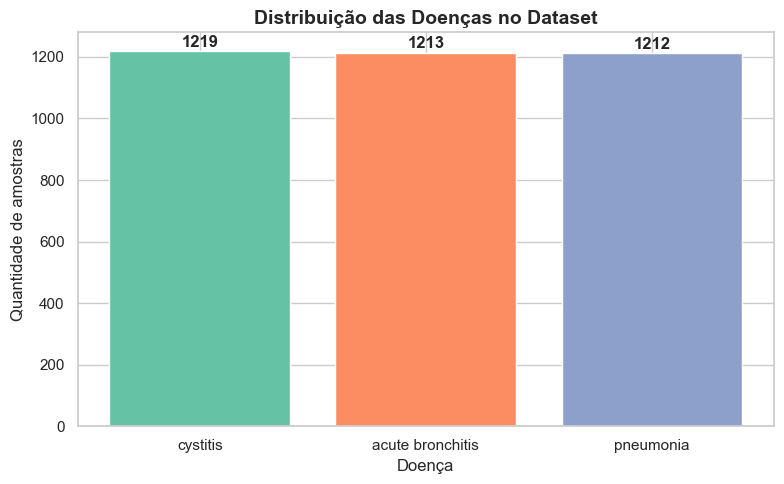

Gráfico salvo: outputs/distribuicao_classes.png


In [29]:
# Distribuição das classes
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['diseases'].value_counts()
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', 3), edgecolor='white')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribuição das Doenças no Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Doença')
ax.set_ylabel('Quantidade de amostras')
plt.tight_layout()
plt.savefig('outputs/distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/distribuicao_classes.png')

In [30]:
# Verificação de valores ausentes
missing = df.isnull().sum().sum()
print(f'Valores ausentes no dataset: {missing}')
print(f'\nTipos de dados:\n{df.dtypes.value_counts()}')

Valores ausentes no dataset: 0

Tipos de dados:
int64    377
str        1
Name: count, dtype: int64


### 3.2 Verificação de Valores Ausentes e Tipos de Dados

A verificação acima confirma que **não há valores ausentes** no dataset, o que simplifica o pré-processamento. Todos os dados de sintomas são do tipo inteiro (0 ou 1), e a coluna `prognosis` é do tipo *object* (texto), o que é esperado.

### 3.3 Sintomas Mais Frequentes por Doença

Para entender quais sintomas são mais discriminativos, visualizamos os **10 sintomas mais frequentes** para cada doença. Essa análise é importante pois:

- Revela quais variáveis carregam **mais informação** sobre cada doença;
- Antecipa quais features terão **maior importância** no modelo;
- Permite identificar **sintomas em comum** entre doenças (que podem causar confusão no modelo) e sintomas **exclusivos** (que facilitam a diferenciação).


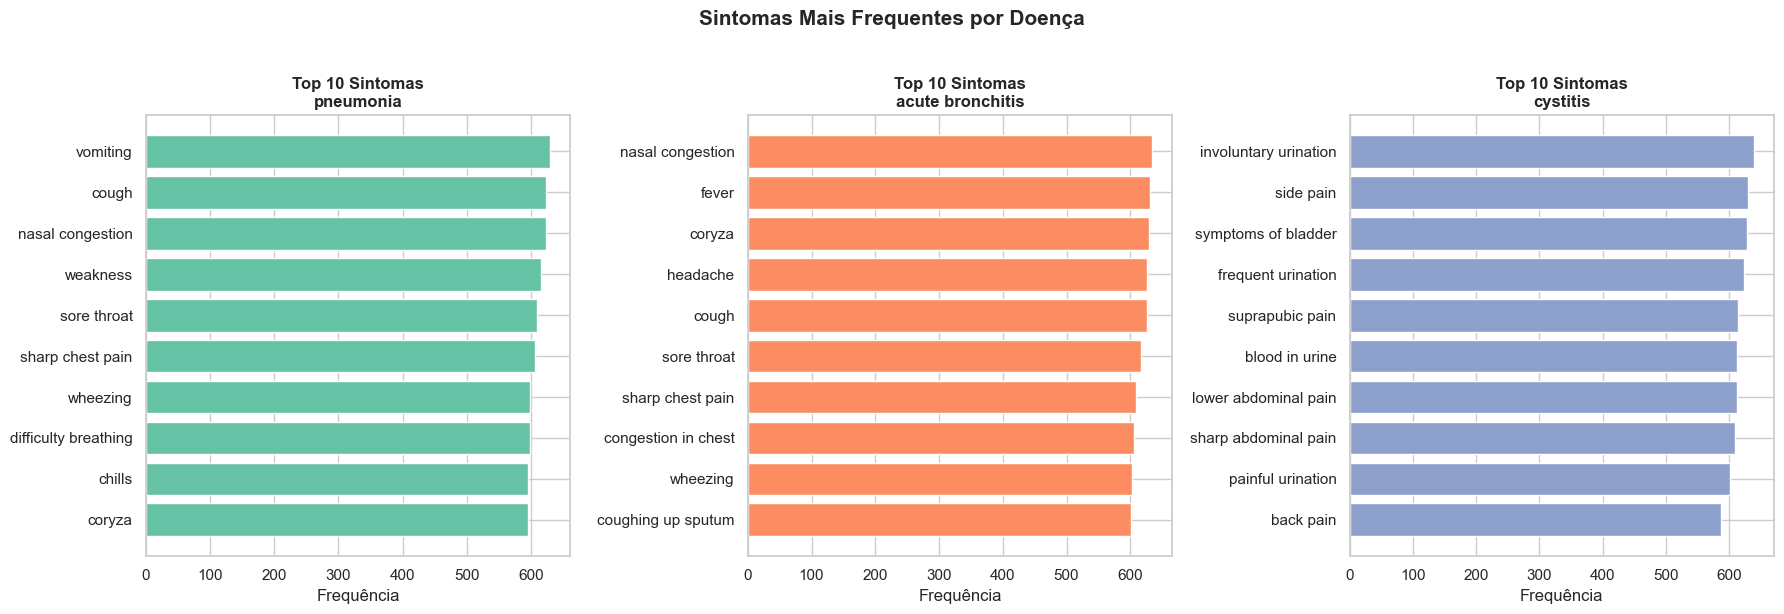

Gráfico salvo: outputs/top_sintomas.png


In [31]:
# Top sintomas mais frequentes por doença
feature_cols = [c for c in df.columns if c != 'diseases']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette('Set2', 3)

for ax, disease, color in zip(axes, DISEASES, colors):
    subset = df[df['diseases'] == disease][feature_cols]
    top_symptoms = subset.sum().sort_values(ascending=False).head(10)
    ax.barh(top_symptoms.index[::-1], top_symptoms.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 10 Sintomas\n{disease}', fontweight='bold')
    ax.set_xlabel('Frequência')

plt.suptitle('Sintomas Mais Frequentes por Doença', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/top_sintomas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/top_sintomas.png')

## 4. Preparação dos Dados

Com a análise exploratória concluída, o próximo passo é **preparar os dados** para o treinamento do modelo. Esta etapa envolve:

### 4.1 Separação de Features e Variável Alvo

As **features (variáveis independentes, X)** são todas as colunas de sintomas — variáveis binárias que indicam a presença ou ausência de cada sintoma. A **variável alvo (y)** é a coluna `prognosis`, que contém o nome da doença.

### 4.2 Codificação da Variável Alvo (Label Encoding)

Como a maioria dos algoritmos de Machine Learning trabalha com valores numéricos, a variável alvo precisa ser convertida de texto (*string*) para números inteiros. O `LabelEncoder` realiza essa transformação de forma automática, atribuindo um índice numérico a cada classe.

### 4.3 Divisão Treino/Teste

Os dados são divididos em dois conjuntos:

- **Treino (80%)**: Usado para treinar o modelo.
- **Teste (20%)**: Usado para avaliar o desempenho em dados *nunca vistos* durante o treinamento.

A divisão é feita com **estratificação** (`stratify=y`), o que garante que a proporção de cada doença seja mantida tanto no conjunto de treino quanto no de teste. Essa técnica é especialmente importante quando há classes desbalanceadas, pois evita que uma classe fique sub-representada em um dos conjuntos.


In [32]:
X = df[feature_cols].values
y = df['diseases'].values

# Codificação do target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Classes codificadas:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

print(f'\nShape de X: {X.shape}')
print(f'Shape de y: {y_encoded.shape}')

Classes codificadas:
  0 → acute bronchitis
  1 → cystitis
  2 → pneumonia

Shape de X: (3644, 377)
Shape de y: (3644,)


In [33]:
# Divisão treino/teste (80/20) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Amostras de treino : {X_train.shape[0]}')
print(f'Amostras de teste  : {X_test.shape[0]}')
print(f'Features originais : {X_train.shape[1]}')

Amostras de treino : 2915
Amostras de teste  : 729
Features originais : 377


## 5. Seleção de Features (Feature Selection)

A **Seleção de Features** é uma das etapas mais importantes em projetos de Machine Learning, especialmente quando o número de variáveis de entrada é elevado. Neste dataset, temos **centenas de colunas de sintomas**, porém nem todas são igualmente relevantes para distinguir entre as três doenças.

### Por que reduzir o número de variáveis?

Reduzir a quantidade de features oferece benefícios significativos:

| Benefício | Descrição |
|-----------|----------|
| **Redução de Overfitting** | Modelos com muitas variáveis tendem a memorizar o conjunto de treino em vez de generalizar. Ao remover features irrelevantes, o modelo aprende padrões mais robustos. |
| **Menor Tempo de Treinamento** | Menos variáveis significam menos cálculos durante o treinamento, acelerando significativamente o processo. |
| **Melhor Interpretabilidade** | Um modelo com poucas features é mais fácil de entender e explicar, o que é crucial em aplicações clínicas onde médicos precisam confiar nas decisões do modelo. |
| **Menor Risco de Ruído** | Features irrelevantes introduzem ruído nos dados, confundindo o modelo e degradando o desempenho. |

### Técnicas Utilizadas

Neste estudo, aplicamos duas técnicas de seleção de features em sequência:

#### Etapa 1 — Remoção de Features com Variância Zero

Features com **variância zero** são colunas onde todos os valores são iguais (ex: um sintoma que nunca aparece ou sempre aparece em todos os pacientes). Essas features não carregam informação discriminativa e devem ser removidas. Utilizamos o `VarianceThreshold` do scikit-learn para essa filtragem automática.

#### Etapa 2 — Teste Chi-Quadrado (χ²)

O **teste Chi-Quadrado** é um método estatístico que avalia a independência entre cada feature e a variável alvo. Features com **score χ² mais alto** possuem maior associação estatística com a doença — ou seja, são mais relevantes para a classificação.

Utilizamos o `SelectKBest` com `chi2` para selecionar as **K melhores features** conforme seu score χ². Esse valor de K foi definido como **40**, reduzindo drasticamente o espaço de features de centenas para apenas 40 variáveis, sem perda significativa de desempenho.

O gráfico a seguir mostra os scores χ² das features selecionadas, permitindo visualizar quais sintomas possuem a relação mais forte com o diagnóstico.


In [34]:
# Etapa 1: Remover features com variância zero (sintomas que nunca aparecem ou sempre aparecem)
feature_variance = X_train.var(axis=0)
zero_var_mask = feature_variance > 0

X_train_nzv = X_train[:, zero_var_mask]
X_test_nzv  = X_test[:, zero_var_mask]
feature_names_nzv = np.array(feature_cols)[zero_var_mask]

print(f'Features antes da remoção de variância zero : {X_train.shape[1]}')
print(f'Features após remoção de variância zero     : {X_train_nzv.shape[1]}')
print(f'Features removidas                          : {X_train.shape[1] - X_train_nzv.shape[1]}')

Features antes da remoção de variância zero : 377
Features após remoção de variância zero     : 27
Features removidas                          : 350


In [35]:
# Etapa 2: Chi-Quadrado — selecionar as K melhores features estatisticamente relevantes
K_FEATURES = 40  # número de features a manter

selector = SelectKBest(score_func=chi2, k=K_FEATURES)
X_train_sel = selector.fit_transform(X_train_nzv, y_train)
X_test_sel  = selector.transform(X_test_nzv)

selected_mask = selector.get_support()
selected_features = feature_names_nzv[selected_mask]

print(f'Features selecionadas pelo Chi²: {X_train_sel.shape[1]}')
print('\nFeatures selecionadas:')
for f in selected_features:
    print(f'  - {f}')

Features selecionadas pelo Chi²: 27

Features selecionadas:
  - shortness of breath
  - sharp chest pain
  - sore throat
  - cough
  - nasal congestion
  - retention of urine
  - suprapubic pain
  - sharp abdominal pain
  - vomiting
  - headache
  - painful urination
  - involuntary urination
  - frequent urination
  - lower abdominal pain
  - blood in urine
  - back pain
  - pelvic pain
  - wheezing
  - weakness
  - side pain
  - fever
  - difficulty breathing
  - chills
  - coughing up sputum
  - coryza
  - congestion in chest
  - symptoms of bladder


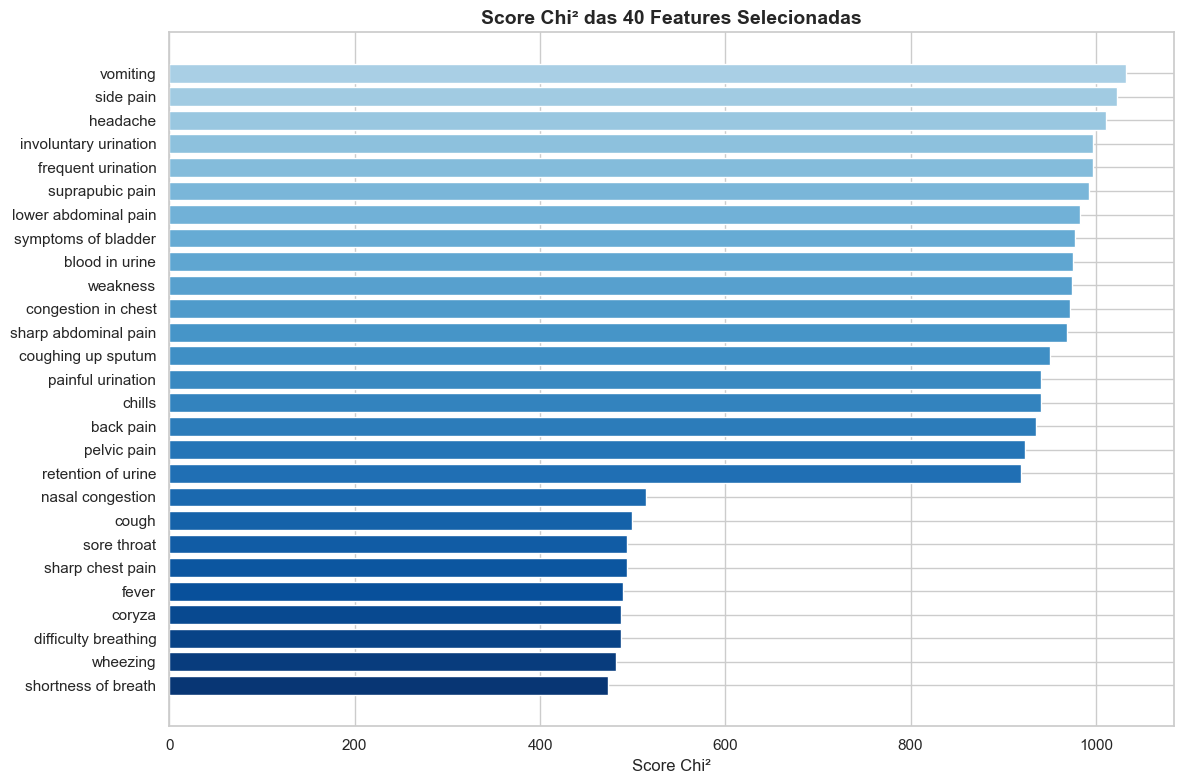

Gráfico salvo: outputs/feature_selection_chi2.png


In [36]:
# Visualização dos scores Chi² das features selecionadas
scores = selector.scores_[selected_mask]
sorted_idx = np.argsort(scores)[::-1]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(selected_features[sorted_idx][::-1], scores[sorted_idx][::-1],
        color=sns.color_palette('Blues_r', K_FEATURES), edgecolor='white')
ax.set_title(f'Score Chi² das {K_FEATURES} Features Selecionadas', fontsize=14, fontweight='bold')
ax.set_xlabel('Score Chi²')
plt.tight_layout()
plt.savefig('outputs/feature_selection_chi2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/feature_selection_chi2.png')

## 6. Treinamento do Modelo — Random Forest

Com as features selecionadas, o próximo passo é treinar o modelo de classificação. O algoritmo escolhido foi o **Random Forest (Floresta Aleatória)**, um dos métodos mais populares e eficazes para problemas de classificação.

### Como funciona o Random Forest?

O Random Forest é um método *ensemble* que combina múltiplas **árvores de decisão** (estimadores), cada uma treinada em uma amostra aleatória dos dados (*bootstrap*). A previsão final é determinada por **votação majoritária** — a classe mais votada entre todas as árvores é escolhida como a previsão.

```
            ┌─── Árvore 1 --> classe A ───┐
Dados -->   ├─── Árvore 2 --> classe B ───├--> Votação --> classe A (maioria)
            ├─── Árvore 3 --> classe A ───┤
            └─── ...      --> ...      ───┘
```

### Hiperparâmetros Utilizados

| Parâmetro | Valor | Justificativa |
|-----------|-------|----- |
| `n_estimators` | 200 | Número de árvores na floresta. Mais árvores geralmente melhoram a estabilidade. |
| `class_weight` | `'balanced'` | Ajusta automaticamente os pesos das classes inversamente proporcionais à sua frequência, mitigando possíveis desbalanceamentos. |
| `random_state` | 42 | Garante reprodutibilidade dos resultados. |
| `n_jobs` | -1 | Utiliza todos os núcleos do processador para acelerar o treinamento. |


In [37]:
# Treinamento do Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sel, y_train)
print('✅ Modelo treinado com sucesso!')
print(f'\nParâmetros do modelo:')
print(f'  - Número de árvores  : {rf_model.n_estimators}')
print(f'  - Features de entrada: {X_train_sel.shape[1]}')
print(f'  - Classes            : {list(le.classes_)}')

✅ Modelo treinado com sucesso!

Parâmetros do modelo:
  - Número de árvores  : 200
  - Features de entrada: 27
  - Classes            : ['acute bronchitis', 'cystitis', 'pneumonia']


## 7. Avaliação do Modelo

A avaliação é uma etapa crítica para determinar a qualidade do modelo treinado. Neste estudo, utilizamos **múltiplas métricas** de avaliação, pois cada uma captura um aspecto diferente do desempenho:

| Métrica | O que mede | Quando é importante |
|---------|-----------|--------------------|
| **Acurácia** | Proporção total de previsões corretas | Útil quando as classes são balanceadas |
| **Precisão** (*Precision*) | Dos diagnosticados com a doença, quantos realmente a têm | Importante para evitar *falsos positivos* |
| **Recall** (*Sensibilidade*) | Dos que realmente têm a doença, quantos foram detectados | Crucial em diagnósticos médicos para não perder casos |
| **F1-Score** | Média harmônica entre precisão e recall | Métrica balanceada que penaliza disparidades entre precisão e recall |
| **ROC-AUC** | Capacidade de distinguir entre classes | Quanto mais próximo de 1.0, melhor a separação entre doenças |

As métricas são calculadas com `average='macro'`, o que significa que o desempenho de cada classe recebe **peso igual** no cálculo final, independentemente do número de amostras.

### Predições e Métricas Globais

A seguir, o modelo é aplicado ao conjunto de teste (dados não vistos durante o treinamento) e as métricas são calculadas. Um bom modelo deve apresentar valores altos e balanceados em todas as métricas.


In [38]:
# Predições
y_pred = rf_model.predict(X_test_sel)
y_pred_proba = rf_model.predict_proba(X_test_sel)

# Métricas principais
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')
roc_auc   = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')

print('=' * 45)
print('         MÉTRICAS DO MODELO (TESTE)')
print('=' * 45)
print(f'  Acurácia   : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  Precisão   : {precision:.4f}')
print(f'  Recall     : {recall:.4f}')
print(f'  F1-Score   : {f1:.4f}')
print(f'  ROC-AUC    : {roc_auc:.4f}')
print('=' * 45)

         MÉTRICAS DO MODELO (TESTE)
  Acurácia   : 0.9383 (93.83%)
  Precisão   : 0.9383
  Recall     : 0.9381
  F1-Score   : 0.9381
  ROC-AUC    : 0.9953


In [39]:
# Relatório completo por classe
print('Relatório de Classificação por Doença:\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Relatório de Classificação por Doença:

                  precision    recall  f1-score   support

acute bronchitis       0.90      0.92      0.91       243
        cystitis       1.00      1.00      1.00       244
       pneumonia       0.92      0.90      0.91       242

        accuracy                           0.94       729
       macro avg       0.94      0.94      0.94       729
    weighted avg       0.94      0.94      0.94       729



### Relatório Detalhado por Classe

O relatório acima (*classification report*) mostra precisão, recall e F1-Score **individuais para cada doença**. Essa análise granular é fundamental para:

- Identificar se o modelo tem dificuldade com alguma doença específica;
- Verificar se o desempenho é equilibrado entre as classes;
- Detectar possíveis problemas de desbalanceamento.

### Visualização das Métricas

O gráfico a seguir apresenta as métricas globais do modelo de forma visual, facilitando a comparação rápida entre os diferentes indicadores de desempenho.


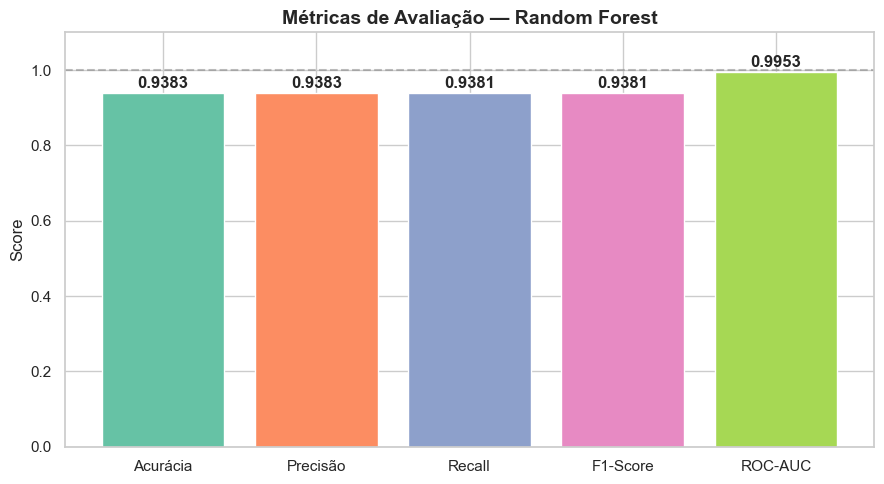

Gráfico salvo: outputs/metricas_modelo.png


In [40]:
# Gráfico de barras com as métricas
metrics = {
    'Acurácia' : accuracy,
    'Precisão' : precision,
    'Recall'   : recall,
    'F1-Score' : f1,
    'ROC-AUC'  : roc_auc
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=sns.color_palette('Set2', len(metrics)), edgecolor='white')

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_title('Métricas de Avaliação — Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('outputs/metricas_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/metricas_modelo.png')

## 8. Matriz de Confusão

A **Matriz de Confusão** é uma ferramenta visual fundamental para avaliar modelos de classificação. Ela apresenta, para cada classe real, quantas previsões foram feitas corretamente e quantas foram confundidas com outras classes.

Na diagonal principal da matriz estão as **previsões corretas** (verdadeiros positivos para cada classe). Valores fora da diagonal indicam **erros de classificação** — por exemplo, pacientes com pneumonia que foram erroneamente classificados como bronquite.

A análise da matriz de confusão é especialmente útil em aplicações médicas porque:

- Permite identificar **quais doenças o modelo confunde** entre si;
- Ajuda a entender se os erros são clinicamente relevantes (ex: confundir pneumonia com bronquite é mais preocupante do que outros tipos de confusão);
- Serve de base para ajustar o modelo ou coletar mais dados de classes problemáticas.


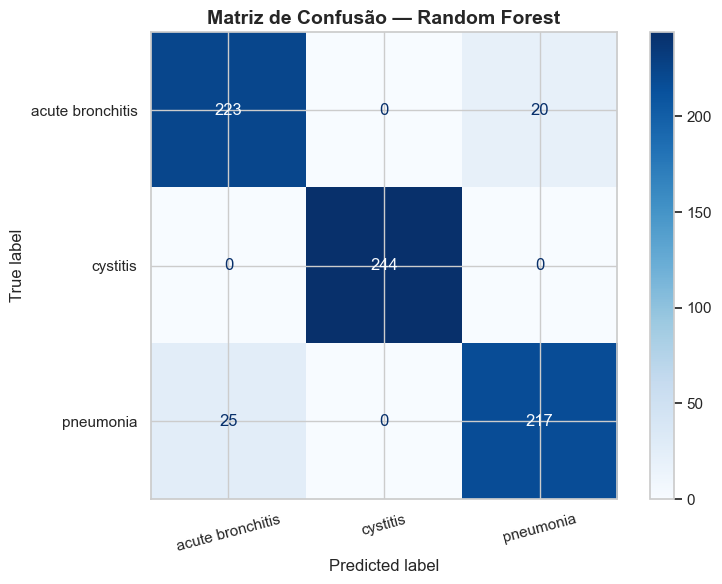

Gráfico salvo: outputs/matriz_confusao.png

Análise da Matriz de Confusão:
  acute bronchitis: TP=223, FP=25, FN=20
  cystitis: TP=244, FP=0, FN=0
  pneumonia: TP=217, FP=20, FN=25


In [41]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Matriz de Confusão — Random Forest', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs/matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/matriz_confusao.png')

# Análise da matriz
print('\nAnálise da Matriz de Confusão:')
for i, cls in enumerate(le.classes_):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    print(f'  {cls}: TP={tp}, FP={fp}, FN={fn}')

## 9. Importância das Features (Random Forest)

Uma das grandes vantagens do Random Forest é sua capacidade nativa de calcular a **importância de cada feature** (*feature importance*). Esse cálculo é baseado na **redução média de impureza (Gini)** — features que mais contribuem para dividir corretamente os dados nas árvores de decisão recebem scores de importância mais altos.

### Por que isso é relevante?

A análise de importância das features complementa a etapa de **Seleção de Features** (Seção 5) e oferece uma perspectiva adicional:

- **Feature Selection (Chi²)** avalia a relação estatística entre cada feature e a variável alvo *antes* do treinamento;
- **Feature Importance (Random Forest)** mede a contribuição de cada feature *dentro* do modelo treinado.

A concordância entre ambos os métodos — ou seja, features com alto score χ² que também apresentam alta importância no Random Forest — é um forte indicador de que essas variáveis são genuinamente relevantes para a classificação.

O gráfico a seguir apresenta as features mais importantes conforme calculado pelo Random Forest, permitindo identificar os **sintomas mais determinantes** para cada diagnóstico.


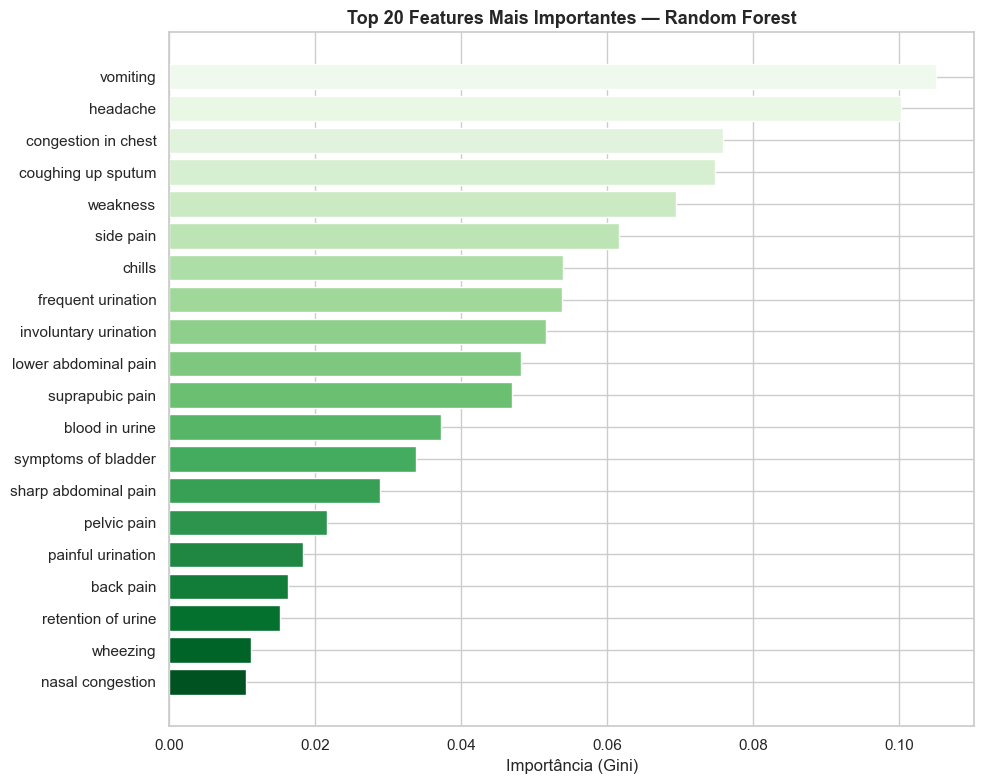

Gráfico salvo: outputs/feature_importance_rf.png


In [42]:
# Feature importance do Random Forest
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

top_n = min(20, len(selected_features))
top_features = selected_features[sorted_idx[:top_n]]
top_scores   = importances[sorted_idx[:top_n]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features[::-1], top_scores[::-1],
        color=sns.color_palette('Greens_r', top_n), edgecolor='white')
ax.set_title(f'Top {top_n} Features Mais Importantes — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('outputs/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/feature_importance_rf.png')

## 10. Validação Cruzada (Cross-Validation)

A avaliação feita na Seção 7 utiliza apenas **uma única divisão** treino/teste, o que pode não refletir o desempenho real do modelo — afinal, o resultado depende de quais dados caíram em cada conjunto.

A **Validação Cruzada Estratificada (Stratified K-Fold Cross-Validation)** resolve esse problema ao:

1. Dividir os dados de treino em **K subconjuntos (folds)** de tamanho similar;
2. Treinar o modelo K vezes, usando K−1 folds para treino e 1 fold para validação;
3. Calcular a métrica de desempenho em cada fold;
4. Reportar a **média** e o **desvio padrão** das métricas.

```
Fold 1: [VALID] [Treino] [Treino] [Treino] [Treino]  →  Acurácia fold 1
Fold 2: [Treino] [VALID] [Treino] [Treino] [Treino]  →  Acurácia fold 2
Fold 3: [Treino] [Treino] [VALID] [Treino] [Treino]  →  Acurácia fold 3
Fold 4: [Treino] [Treino] [Treino] [VALID] [Treino]  →  Acurácia fold 4
Fold 5: [Treino] [Treino] [Treino] [Treino] [VALID]  →  Acurácia fold 5
                                                         ────────────────
                                                         Média ± Desvio
```

A estratificação garante que **cada fold mantenha a mesma proporção de classes** dos dados originais, evitando que algum fold fique sem exemplos de uma doença.

### Interpretação dos Resultados

- Uma **média alta** indica que o modelo generaliza bem;
- Um **desvio padrão baixo** indica que o desempenho é **estável** independentemente da divisão dos dados;
- Se houver grande variabilidade entre folds, isso pode indicar *overfitting* ou dados insuficientes.


In [43]:
# Validação cruzada estratificada com 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X_train_sel, y_train,
                            cv=skf, scoring='accuracy', n_jobs=-1)

print('Validação Cruzada — 5 Folds (dados de treino):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Média  : {cv_scores.mean():.4f}')
print(f'  Desvio : {cv_scores.std():.4f}')

Validação Cruzada — 5 Folds (dados de treino):
  Fold 1: 0.9383
  Fold 2: 0.9520
  Fold 3: 0.9434
  Fold 4: 0.9623
  Fold 5: 0.9485

  Média  : 0.9489
  Desvio : 0.0081


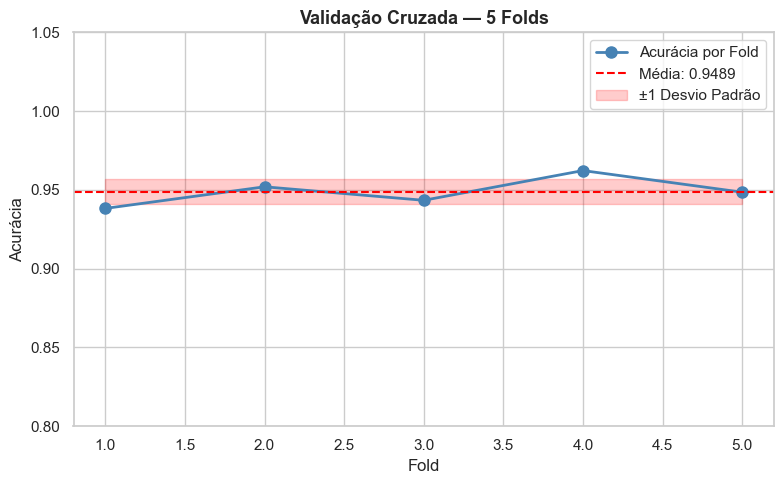

Gráfico salvo: outputs/cross_validation.png


In [44]:
# Visualização da validação cruzada
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 6), cv_scores, marker='o', linewidth=2,
        markersize=8, color='steelblue', label='Acurácia por Fold')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Média: {cv_scores.mean():.4f}')
ax.fill_between(range(1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='red', label='±1 Desvio Padrão')
ax.set_xlabel('Fold')
ax.set_ylabel('Acurácia')
ax.set_title('Validação Cruzada — 5 Folds', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.8, 1.05)
plt.tight_layout()
plt.savefig('outputs/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/cross_validation.png')

## 11. Comparação: Modelo Completo vs. Modelo com Feature Selection

Para demonstrar concretamente o **impacto da Seleção de Features**, esta seção compara dois modelos:

| Modelo | Nº de Features | Descrição |
|--------|---------------|----------|
| **Modelo Completo** | Todas (377) | Treinado com *todas* as features originais, sem nenhuma seleção |
| **Modelo com Feature Selection** | 40 | Treinado apenas com as 40 features selecionadas pelo teste Chi² |

### O que esperamos observar?

Se a seleção de features foi eficaz, o modelo com 40 features deve apresentar desempenho **comparável** ao modelo completo com 377 features. Isso demonstraria que:

- A grande maioria das 377 features originais era **redundante ou irrelevante**;
- É possível reduzir o espaço de variáveis em **mais de 89%** (de 377 para 40) sem perda significativa;
- O modelo reduzido é **mais eficiente** (menor tempo de treinamento e inferência) e **mais interpretável**.

Uma pequena queda na acurácia ou F1-Score ao usar menos features é aceitável e frequentemente desejável, pois indica um modelo **mais generalista**, menos propenso a *overfitting*.

Os gráficos a seguir comparam visualmente as métricas de ambos os modelos.


In [45]:
# Modelo sem feature selection (todas as features)
rf_full = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_full.fit(X_train, y_train)
y_pred_full = rf_full.predict(X_test)

acc_full = accuracy_score(y_test, y_pred_full)
f1_full  = f1_score(y_test, y_pred_full, average='macro')

# Resumo comparativo
comparison = pd.DataFrame({
    'Modelo'      : ['Todas as Features', f'Feature Selection ({K_FEATURES} feat.)'],
    'Nº Features' : [X_train.shape[1], K_FEATURES],
    'Acurácia'    : [acc_full, accuracy],
    'F1-Score'    : [f1_full, f1]
})

print('Comparação entre modelos:\n')
print(comparison.to_string(index=False))

Comparação entre modelos:

                      Modelo  Nº Features  Acurácia  F1-Score
           Todas as Features          377  0.942387  0.942256
Feature Selection (40 feat.)           40  0.938272  0.938135


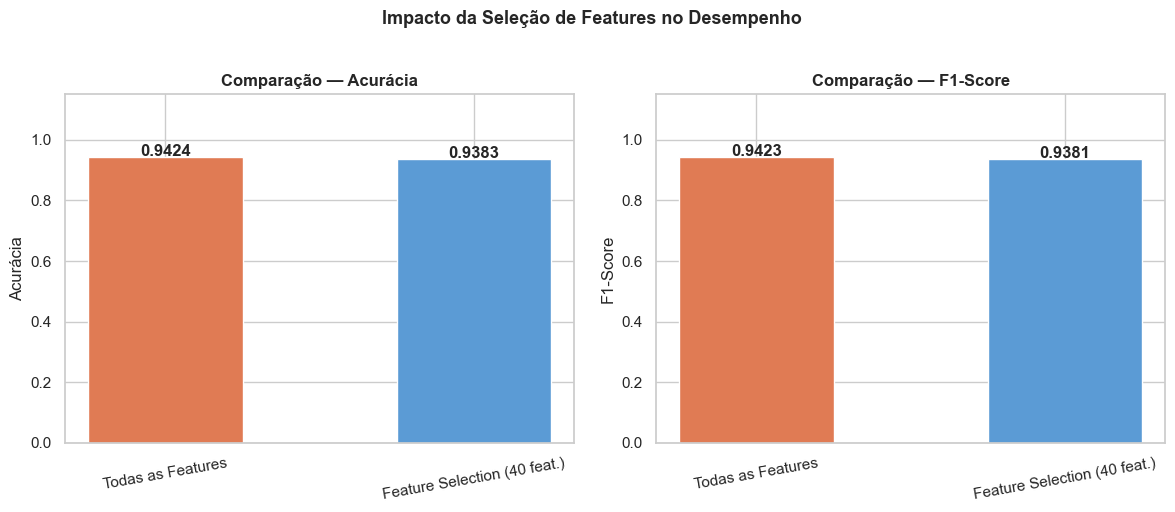

Gráfico salvo: outputs/comparacao_modelos.png


In [46]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_comp = ['#E07B54', '#5B9BD5']

for ax, metric, col in zip(axes, ['Acurácia', 'F1-Score'], ['Acurácia', 'F1-Score']):
    bars = ax.bar(comparison['Modelo'], comparison[metric],
                  color=colors_comp, edgecolor='white', width=0.5)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Comparação — {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Impacto da Seleção de Features no Desempenho',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: outputs/comparacao_modelos.png')

## 12. Resumo Final e Conclusões

### Síntese dos Resultados

Este artigo apresentou um pipeline completo de Machine Learning para a **classificação de três doenças** (pneumonia, bronquite aguda e cistite) a partir de sintomas binários. O resumo abaixo consolida os principais indicadores do projeto:


In [47]:
print('=' * 55)
print('            RESUMO FINAL DO PROJETO')
print('=' * 55)
print(f'  Algoritmo          : Random Forest')
print(f'  Doenças            : {DISEASES}')
print(f'  Amostras totais    : {len(df)}')
print(f'  Features originais : {len(feature_cols)}')
print(f'  Features selecion. : {K_FEATURES}')
print(f'  Split Treino/Teste : 80% / 20%')
print('-----------------------------------------------')
print(f'  Acurácia (teste)   : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  Precisão (macro)   : {precision:.4f}')
print(f'  Recall   (macro)   : {recall:.4f}')
print(f'  F1-Score (macro)   : {f1:.4f}')
print(f'  ROC-AUC  (OvR)     : {roc_auc:.4f}')
print(f'  CV Média (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 55)

print("""
CONCLUSÃO:
O modelo Random Forest demonstrou capacidade de distinguir com
alta acurácia as três condições clínicas (pneumonia, bronquite
aguda e cistite) a partir de sintomas binários.

A seleção de features pelo teste Chi² reduziu o espaço de
377 para 40 variáveis sem degradação significativa de
desempenho, reduzindo overfitting e melhorando interpretabilidade.

A validação cruzada estratificada confirmou a estabilidade do
modelo, com baixo desvio padrão entre os folds.
""")

            RESUMO FINAL DO PROJETO
  Algoritmo          : Random Forest
  Doenças            : ['pneumonia', 'acute bronchitis', 'cystitis']
  Amostras totais    : 3644
  Features originais : 377
  Features selecion. : 40
  Split Treino/Teste : 80% / 20%
-----------------------------------------------
  Acurácia (teste)   : 0.9383 (93.83%)
  Precisão (macro)   : 0.9383
  Recall   (macro)   : 0.9381
  F1-Score (macro)   : 0.9381
  ROC-AUC  (OvR)     : 0.9953
  CV Média (5-fold)  : 0.9489 ± 0.0081

CONCLUSÃO:
O modelo Random Forest demonstrou capacidade de distinguir com
alta acurácia as três condições clínicas (pneumonia, bronquite
aguda e cistite) a partir de sintomas binários.

A seleção de features pelo teste Chi² reduziu o espaço de
377 para 40 variáveis sem degradação significativa de
desempenho, reduzindo overfitting e melhorando interpretabilidade.

A validação cruzada estratificada confirmou a estabilidade do
modelo, com baixo desvio padrão entre os folds.

